In [2]:
!pip install pandas
!pip install matplotlib
!pip install -U scikit-learn

   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.1 MB 2.4 MB/s eta 0:00:05
   --- ------------------------------------ 1.0/11.1 MB 3.0 MB/s eta 0:00:04
   ------ --------------------------------- 1.8/11.1 MB 3.1 MB/s eta 0:00:04
   --------- ------------------------------ 2.6/11.1 MB 3.4 MB/s eta 0:00:03
   ------------ --------------------------- 3.4/11.1 MB 3.4 MB/s eta 0:00:03
   --------------- ------------------------ 4.2/11.1 MB 3.5 MB/s eta 0:00:02
   ----------------- ---------------------- 5.0/11.1 MB 3.6 MB/s eta 0:00:02
   --------------------- ------------------ 6.0/11.1 MB 3.8 MB/s eta 0:00:02
   ------------------------ --------------- 6.8/11.1 MB 3.9 MB/s eta 0:00:02
   ---------------------------- ----------- 7.9/11.1 MB 3.9 MB/s eta 0:00:01
   -------------------------------- ------- 8.9/11.1 MB 4.0 MB/s eta 0:00:01
   ---------------------------------- ----- 9.7/11.1 MB 4.0 MB/s eta 0:00:01
   ---

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def check_distribution_and_nulls(df):
    # Check for null values
    print("Null Values in Each Column:")
    print(df.isnull().sum())
    print("\nPercentage of Nulls:")
    print((df.isnull().mean() * 100).round(2))

    # Plot distribution for each column
    for column in df.columns:
        plt.figure(figsize=(8, 4))
        if pd.api.types.is_numeric_dtype(df[column]):
            sns.histplot(df[column].dropna(), kde=True, bins=30)
        else:
            df[column].value_counts(dropna=False).plot(kind='bar')
        plt.title(f'Distribution of "{column}"')
        plt.xlabel(column)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()


columns_to_impute = ['Q1', 'Q2']

Null Values in Each Column:
ï»¿provnum                      0
Year                            0
PROVNAME                        0
ADDRESS                         0
CITY                            0
STATE                           0
ZIP                             0
OWNERSHIP                       1
BEDCERT                         0
RESTOT                        588
CERTIFICATION                   0
INHOSP                          0
overall_rating               1252
survey_rating                 808
quality_rating                949
staffing_rating              2338
RN_staffing_rating           2338
AIDHRD                       2699
VOCHRD                       2699
RNHRD                        2699
TOTLICHRD                    2699
TOTHRD                       2699
PTHRD                        2708
exp_aide                     1702
exp_lpn                      1702
exp_rn                       1702
exp_total                    1702
adj_aide                     3016
adj_lpn             

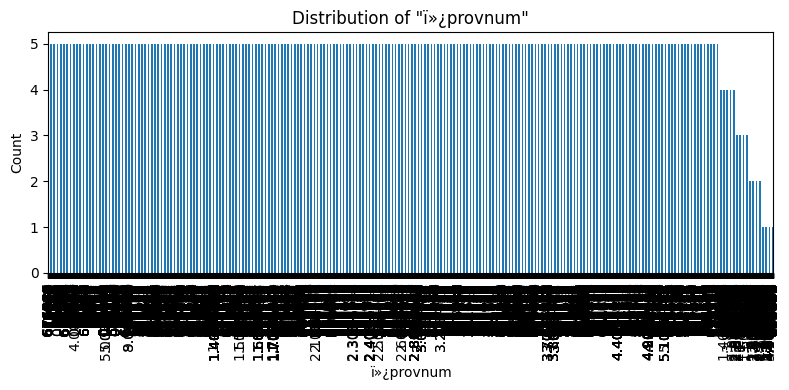

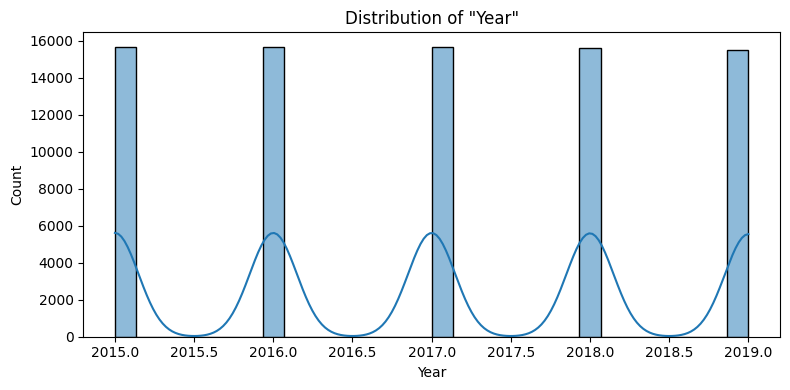

C:\Users\Julian Amberg\AppData\Local\Temp\ipykernel_17656\3201632584.py:25: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Julian Amberg\AppData\Local\Temp\ipykernel_17656\3201632584.py:25: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Julian Amberg\AppData\Local\Temp\ipykernel_17656\3201632584.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
c:\Users\Julian Amberg\Desktop\Data Science\Python_Work\622_Programming\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Julian Amberg\Desktop\Data Science\Python_Work\622_Programming\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figur

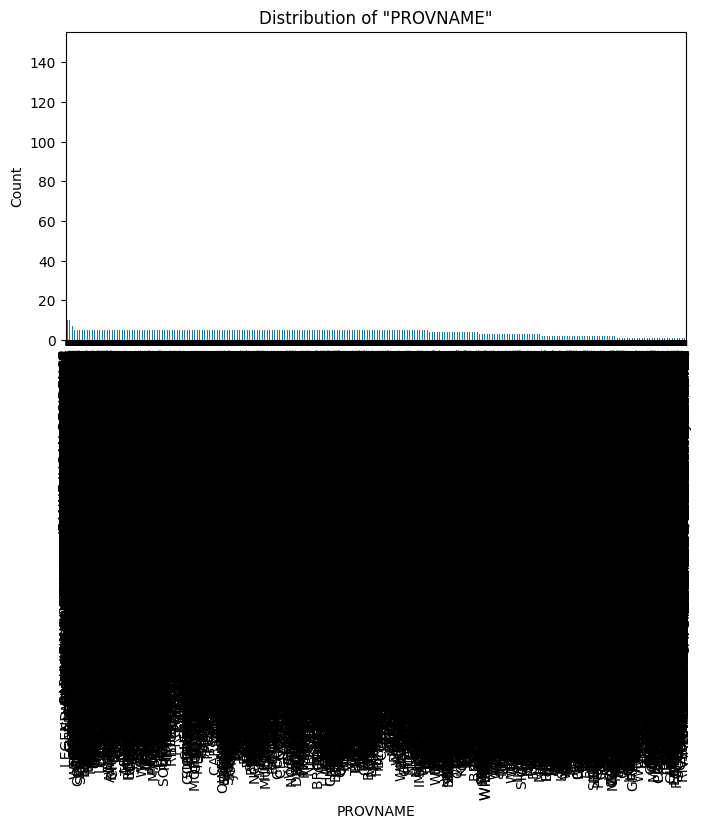

C:\Users\Julian Amberg\AppData\Local\Temp\ipykernel_17656\3201632584.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


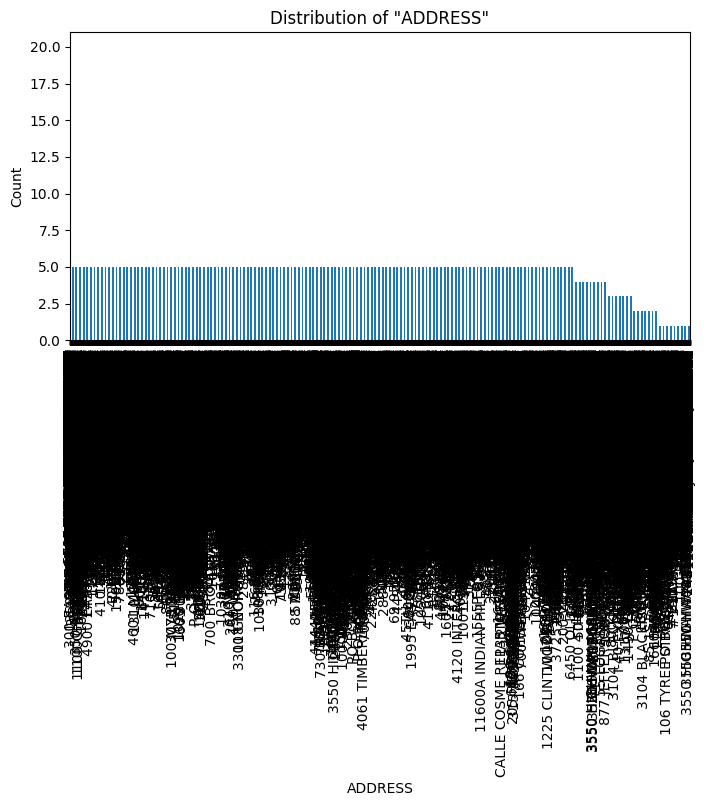

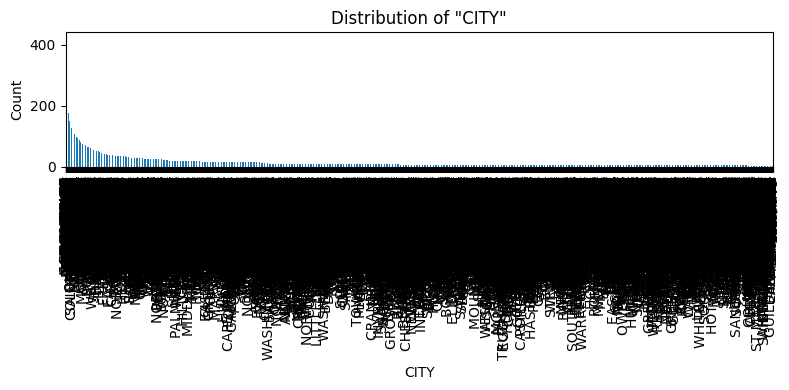

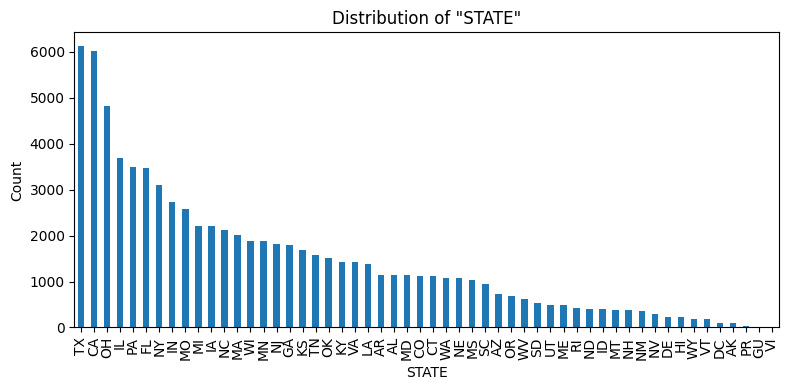

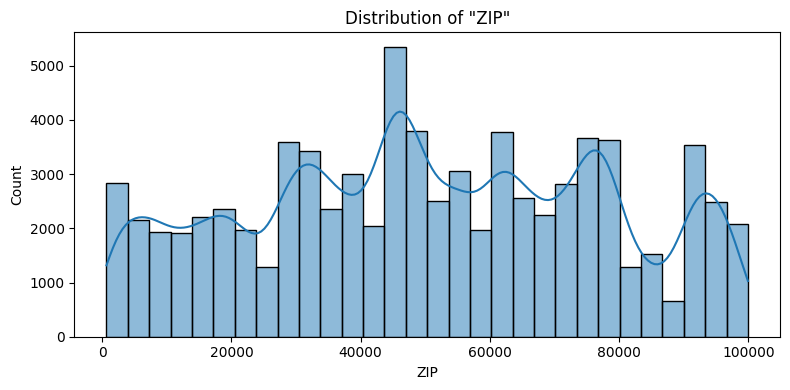

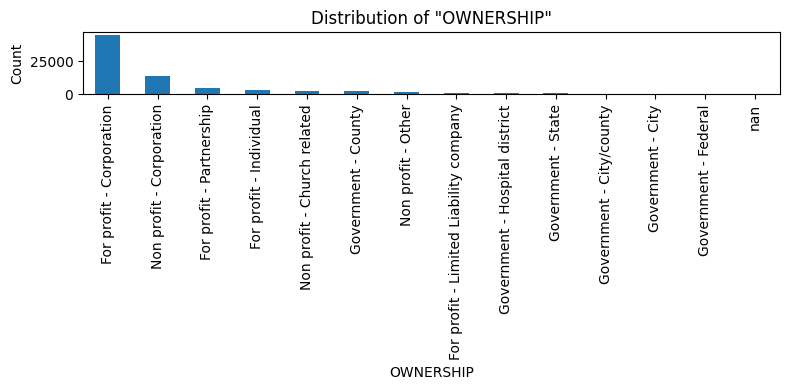

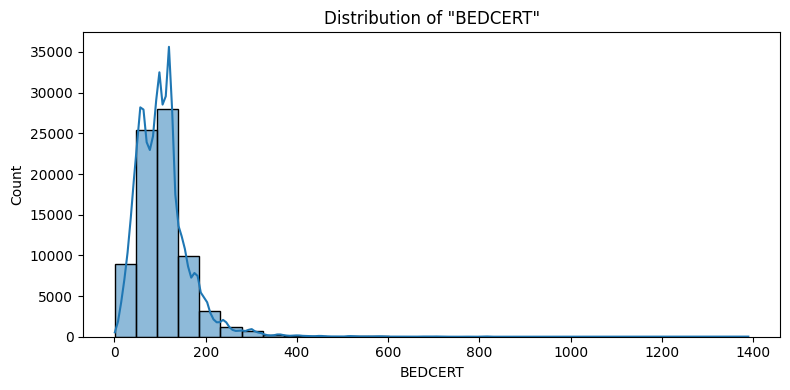

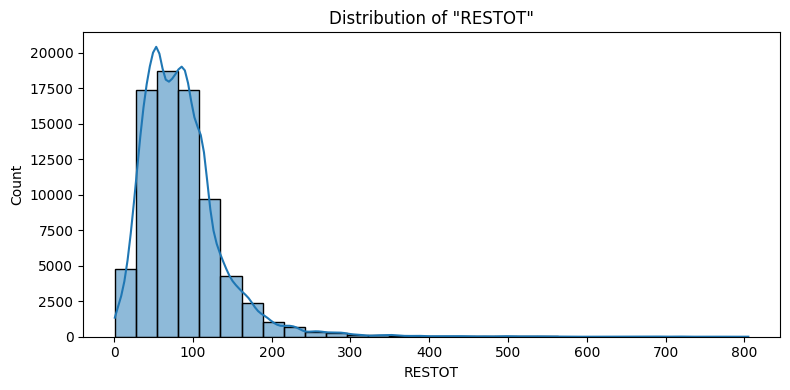

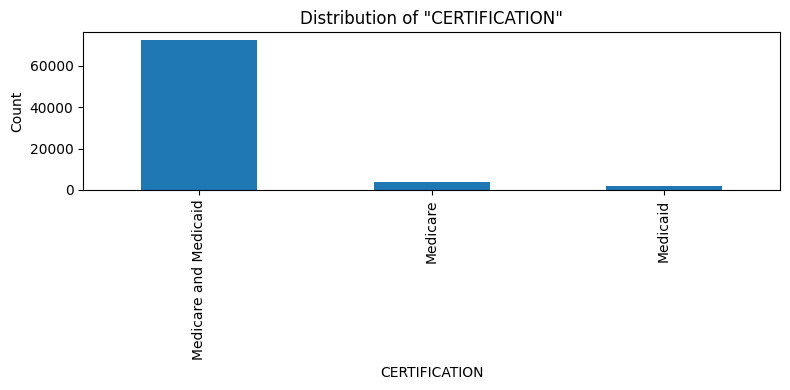

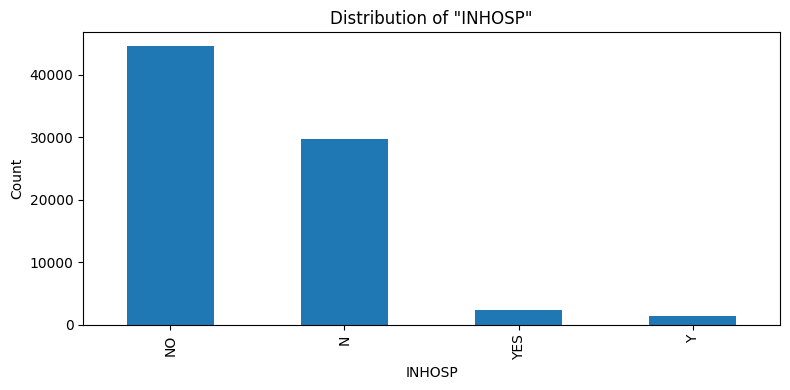

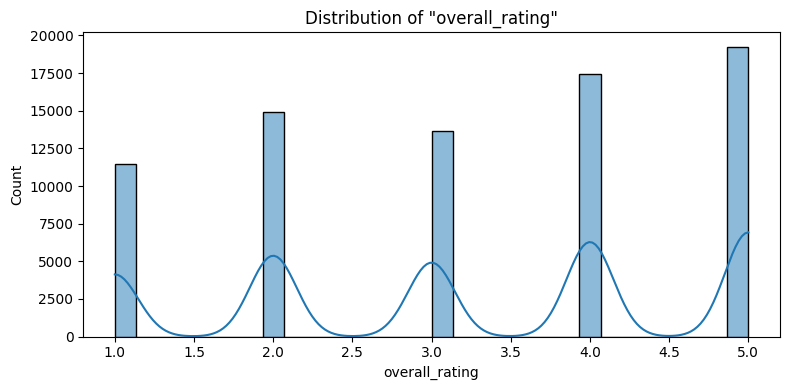

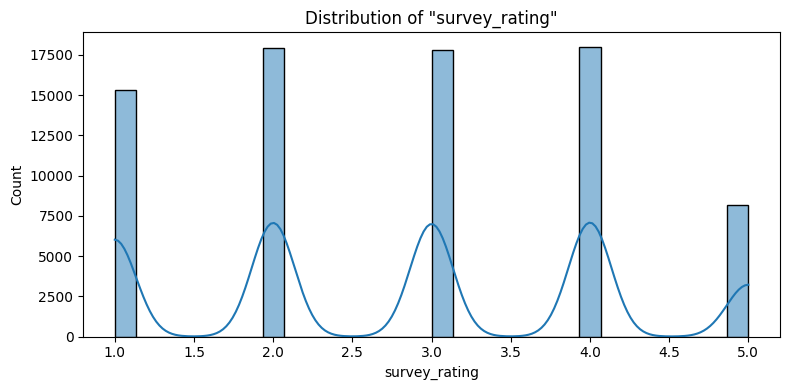

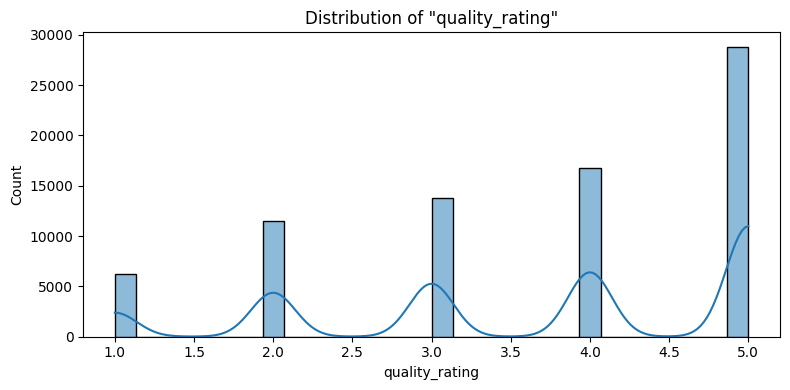

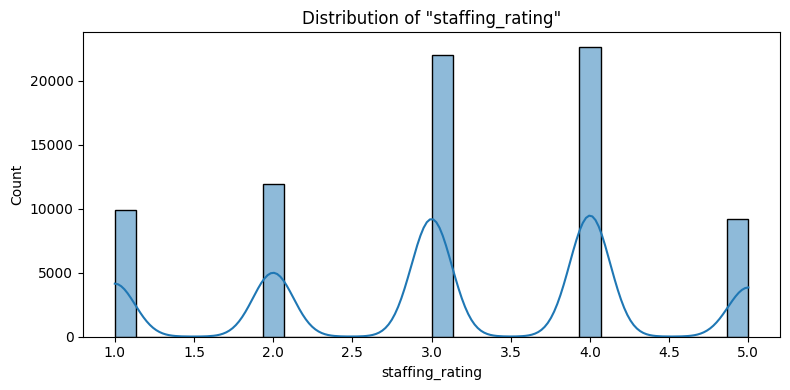

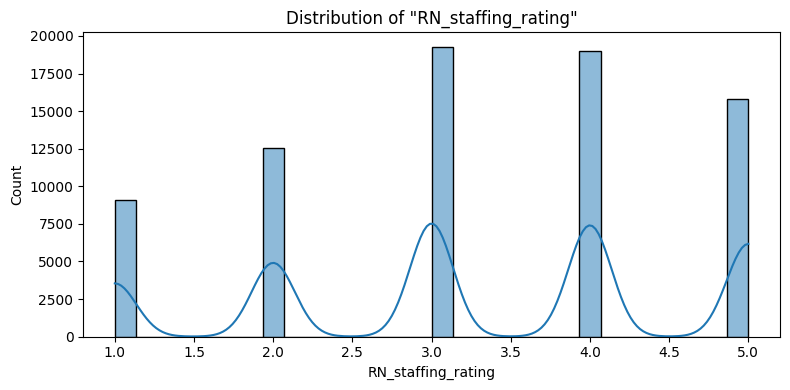

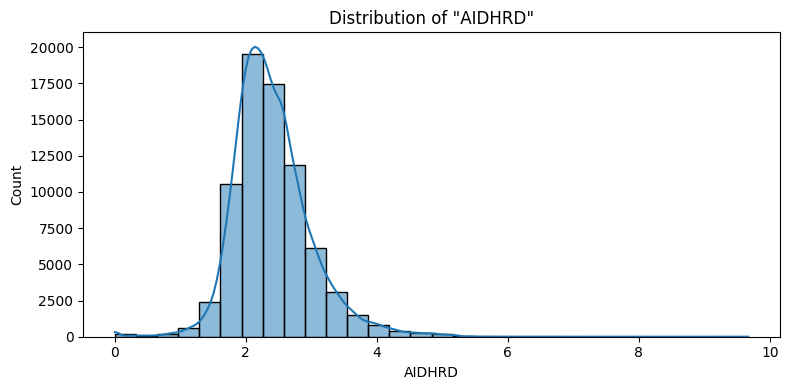

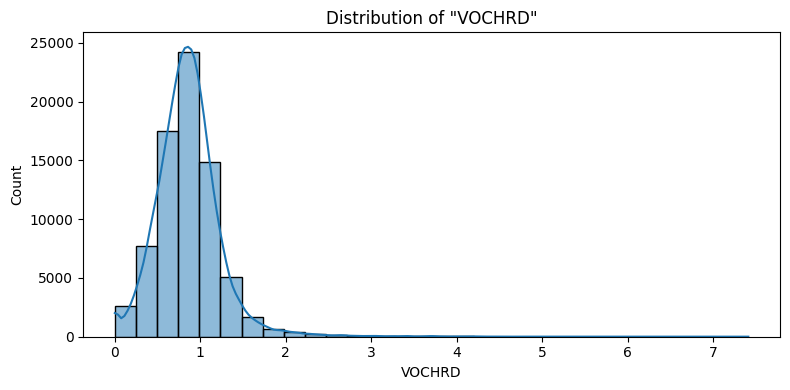

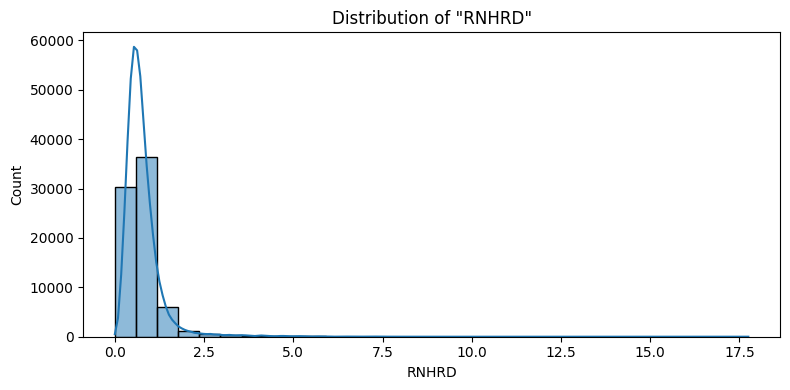

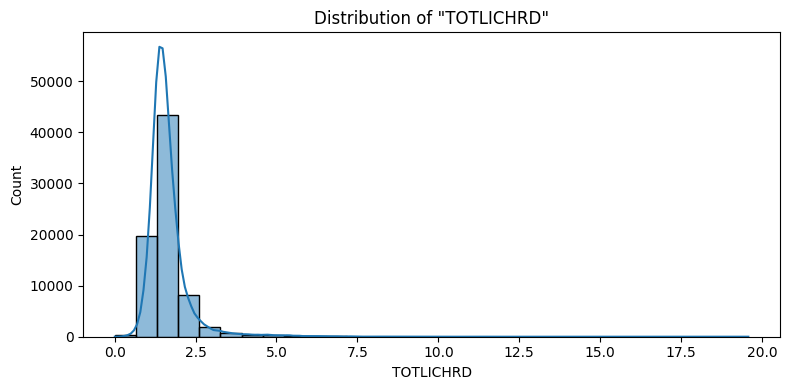

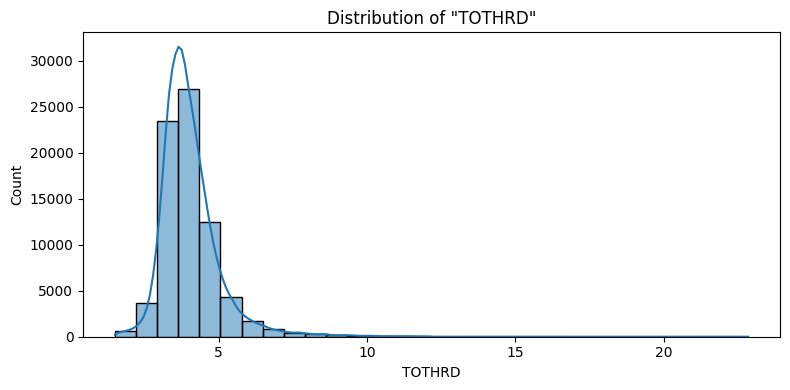

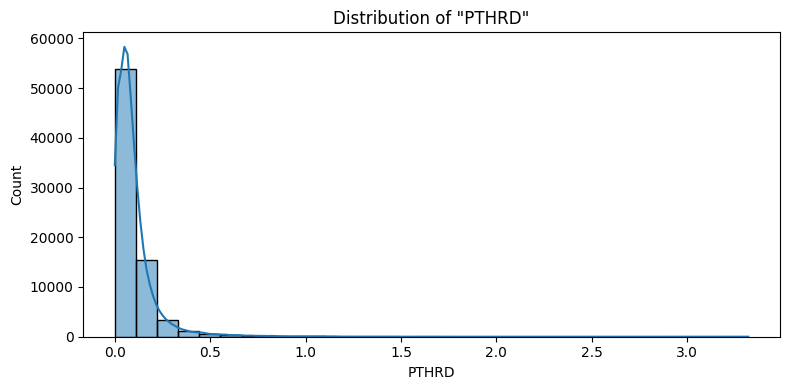

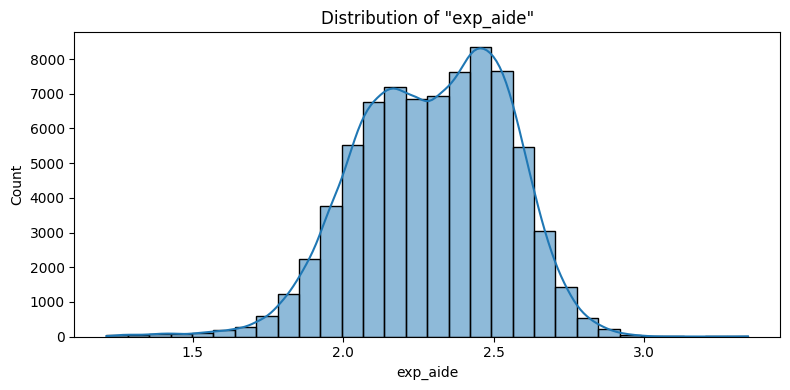

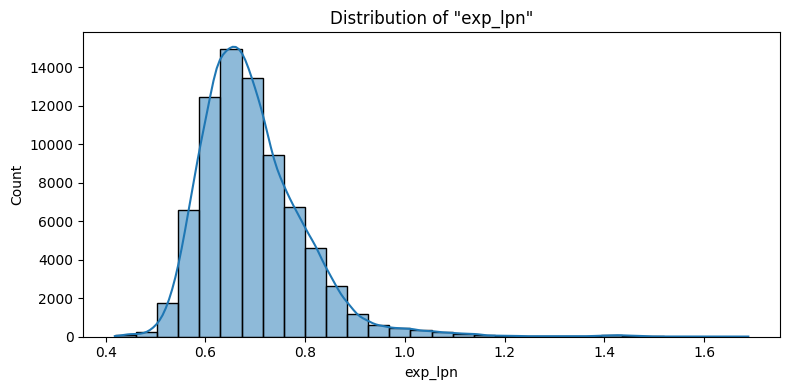

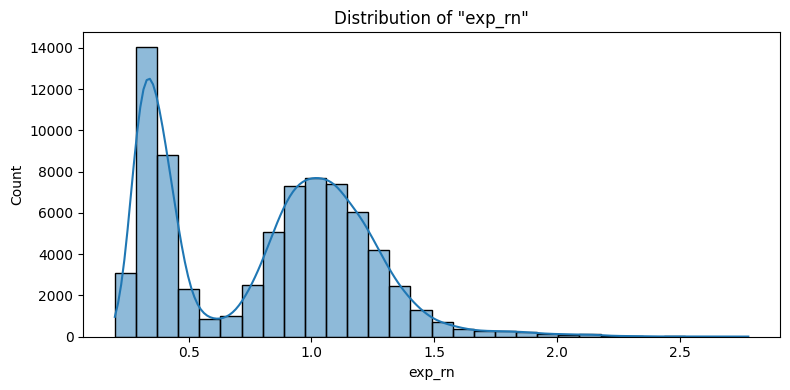

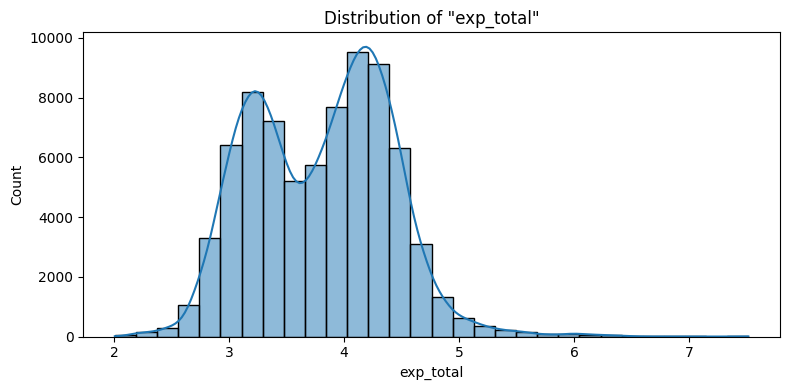

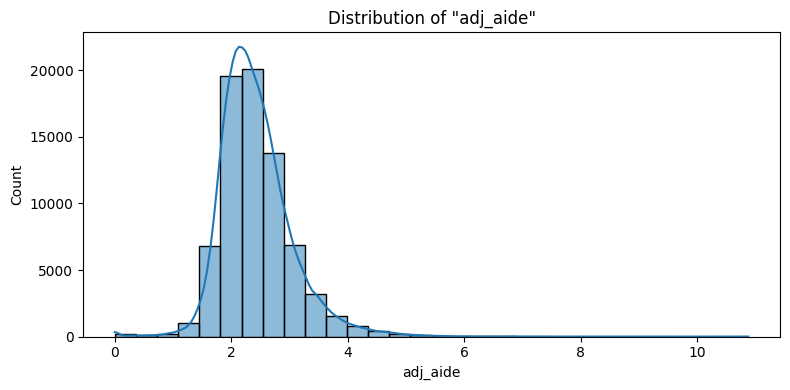

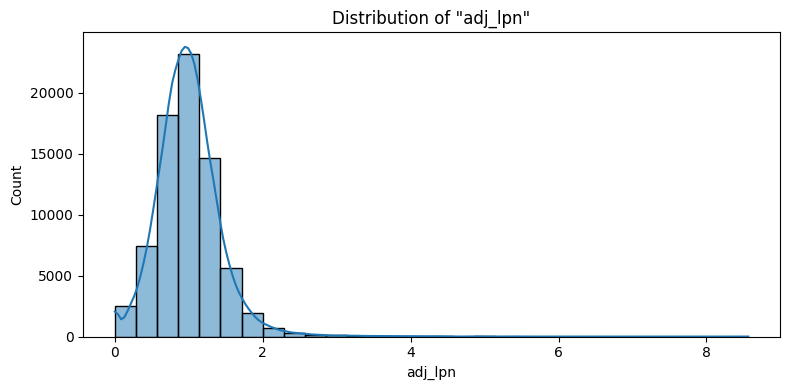

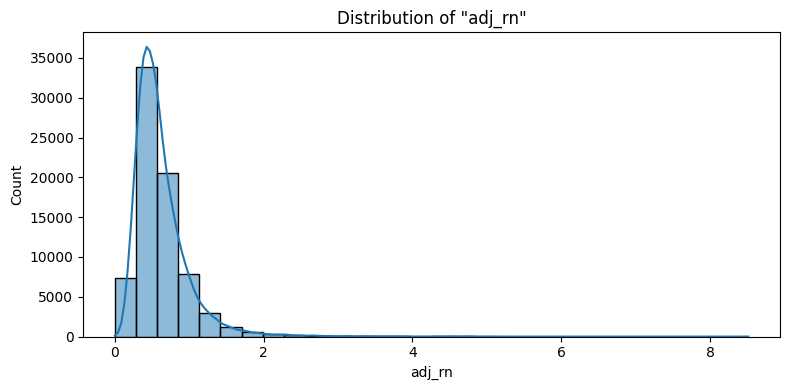

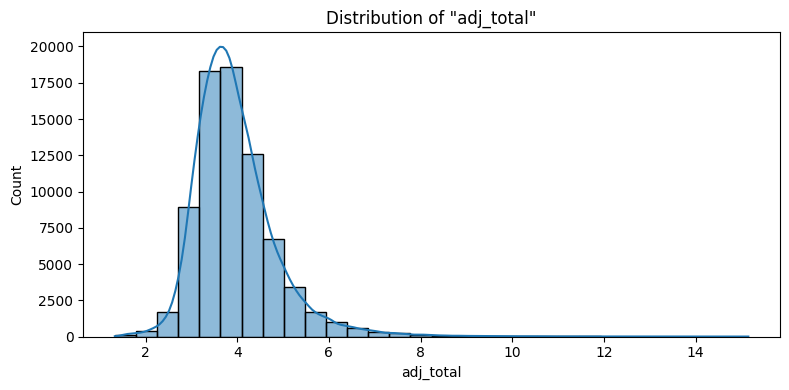

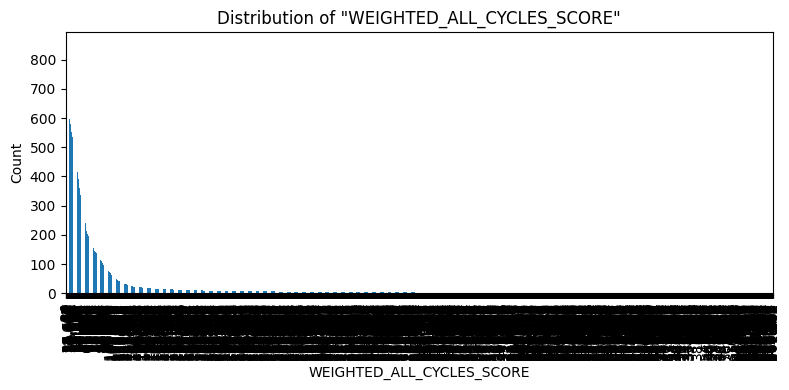

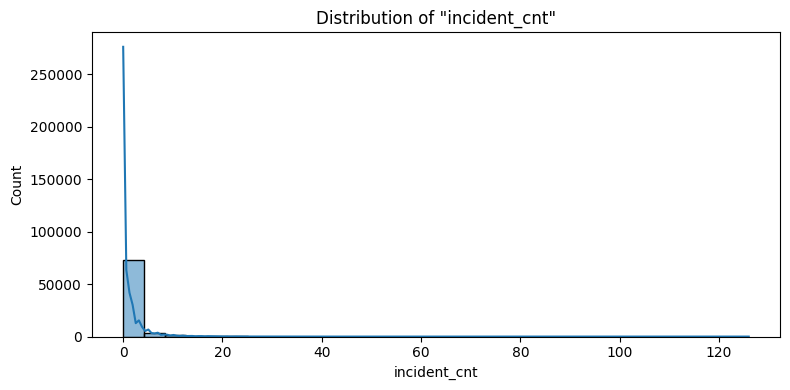

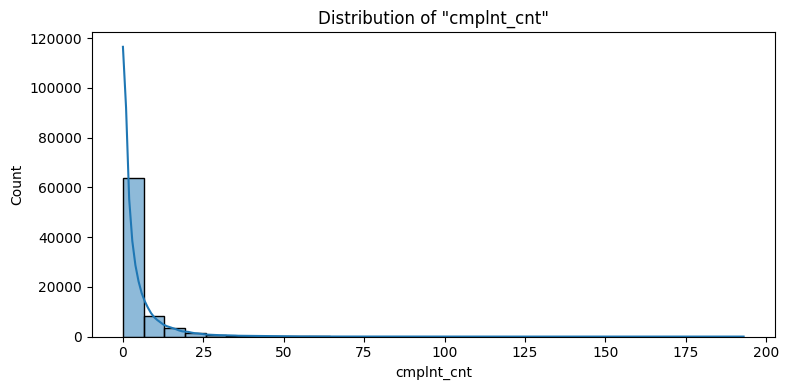

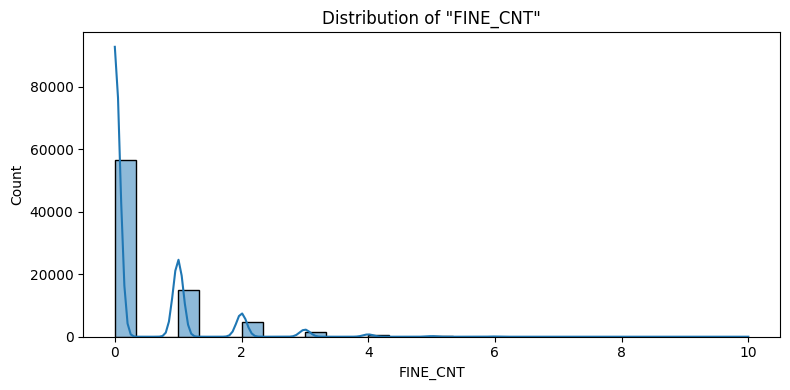

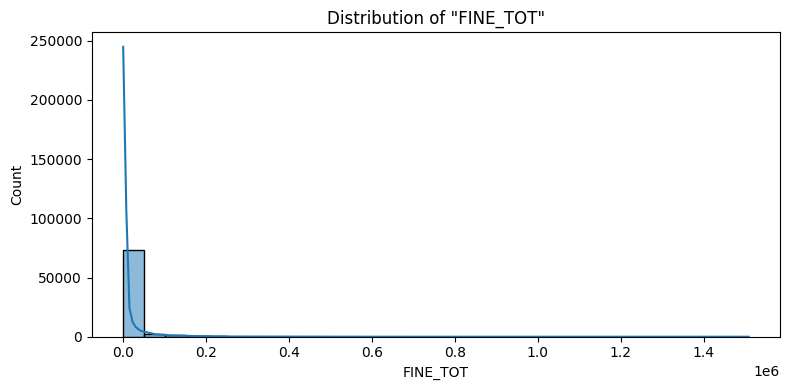

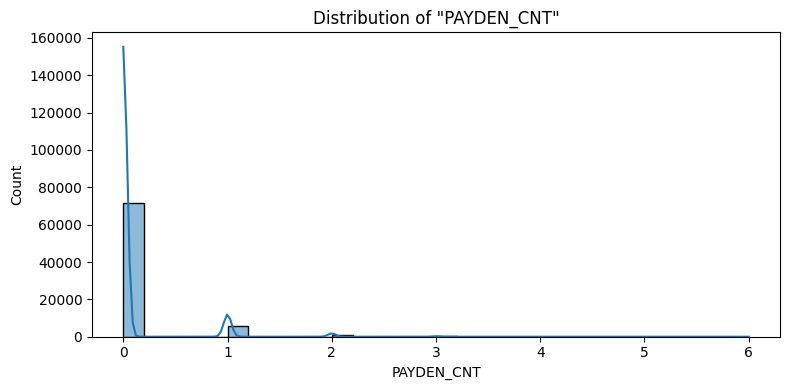

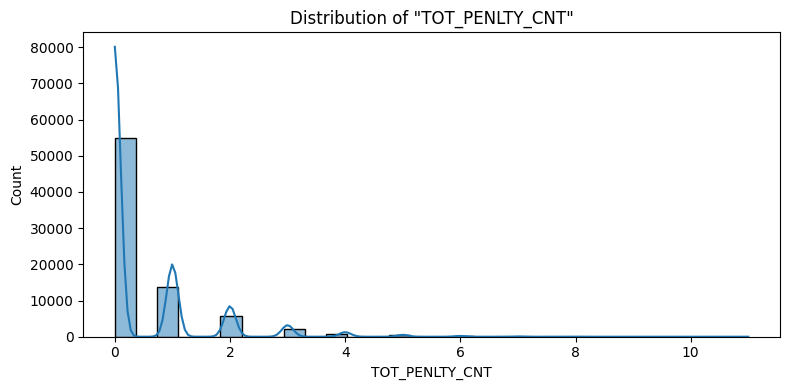

In [8]:
df = pd.read_csv("ProviderInfo_ALLRedone.csv", encoding='ISO-8859-1')
check_distribution_and_nulls(df)

In [9]:
def remove_nulls_from_columns(df, column_list):
    cleaned_df = df.dropna(subset=column_list).copy()
    return cleaned_df

# Remove rows where columns are null
columns_to_check = ['overall_rating', 'quality_rating', 'staffing_rating', 'RN_staffing_rating']
df_cleaned = remove_nulls_from_columns(df, columns_to_check)

print(f"Original rows: {len(df)}, Cleaned rows: {len(df_cleaned)}")

Original rows: 78025, Cleaned rows: 75610


In [10]:
def check_distribution_and_nulls(df_cleaned):
    # Check for null values
    print("Null Values in Each Column:")
    print(df_cleaned.isnull().sum())
    print("\nPercentage of Nulls:")
    print((df_cleaned.isnull().mean() * 100).round(2))

    # Plot distribution for each column
    # for column in df.columns:
    #     plt.figure(figsize=(8, 4))
    #     if pd.api.types.is_numeric_dtype(df[column]):
    #         sns.histplot(df_cleaned[column].dropna(), kde=True, bins=30)
    #     else:
    #         df_cleaned[column].value_counts(dropna=False).plot(kind='bar')
    #     plt.title(f'Distribution of "{column}"')
    #     plt.xlabel(column)
    #     plt.ylabel("Count")
    #     plt.tight_layout()
    #     plt.show()

check_distribution_and_nulls(df_cleaned)

Null Values in Each Column:
ï»¿provnum                      0
Year                            0
PROVNAME                        0
ADDRESS                         0
CITY                            0
STATE                           0
ZIP                             0
OWNERSHIP                       1
BEDCERT                         0
RESTOT                        427
CERTIFICATION                   0
INHOSP                          0
overall_rating                  0
survey_rating                   0
quality_rating                  0
staffing_rating                 0
RN_staffing_rating              0
AIDHRD                       1151
VOCHRD                       1151
RNHRD                        1151
TOTLICHRD                    1151
TOTHRD                       1151
PTHRD                        1160
exp_aide                     1151
exp_lpn                      1151
exp_rn                       1151
exp_total                    1151
adj_aide                     1151
adj_lpn             

In [11]:
def remove_outliers_iqr(df_cleaned):
    numeric_cols = df_cleaned.select_dtypes(include='number').columns
    clean_df = df_cleaned.copy()

    for col in numeric_cols:
        Q1 = clean_df[col].quantile(0.25)
        Q3 = clean_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Keep only rows within bounds
        clean_df = clean_df[(clean_df[col] >= lower_bound) & (clean_df[col] <= upper_bound)]

    return clean_df

df_no_outliers = remove_outliers_iqr(df_cleaned)

print(f"Original rows: {len(df)}, After IQR filtering: {len(df_no_outliers)}")

Original rows: 78025, After IQR filtering: 32779


In [12]:
def check_distribution_and_nulls(df_no_outliers):
    # Check for null values
    print("Null Values in Each Column:")
    print(df_no_outliers.isnull().sum())
    print("\nPercentage of Nulls:")
    print((df_no_outliers.isnull().mean() * 100).round(2))

    # Plot distribution for each column
    # for column in df_no_outliers.columns:
    #     plt.figure(figsize=(8, 4))
    #     if pd.api.types.is_numeric_dtype(df_no_outliers[column]):
    #         sns.histplot(df_no_outliers[column].dropna(), kde=True, bins=30)
    #     else:
    #         df_no_outliers[column].value_counts(dropna=False).plot(kind='bar')
    #     plt.title(f'Distribution of "{column}"')
    #     plt.xlabel(column)
    #     plt.ylabel("Count")
    #     plt.tight_layout()
    #     plt.show()

check_distribution_and_nulls(df_no_outliers)

Null Values in Each Column:
ï»¿provnum                   0
Year                         0
PROVNAME                     0
ADDRESS                      0
CITY                         0
STATE                        0
ZIP                          0
OWNERSHIP                    0
BEDCERT                      0
RESTOT                       0
CERTIFICATION                0
INHOSP                       0
overall_rating               0
survey_rating                0
quality_rating               0
staffing_rating              0
RN_staffing_rating           0
AIDHRD                       0
VOCHRD                       0
RNHRD                        0
TOTLICHRD                    0
TOTHRD                       0
PTHRD                        0
exp_aide                     0
exp_lpn                      0
exp_rn                       0
exp_total                    0
adj_aide                     0
adj_lpn                      0
adj_rn                       0
adj_total                    0
WEIGHTED_AL

In [15]:
df_no_outliers.to_csv('ProviderInfo1519_Cleaned.csv', index=False)

In [22]:
df = pd.read_csv("ProviderInfo1519_IQRCleaned.csv", encoding='ISO-8859-1')

value_counts = df['provnum'].value_counts()

print(value_counts)

# Keep only values that appear exactly 5 times
valid_values = value_counts[value_counts == 5].index

# Filter the DataFrame
filtered_df = df[df['provnum'].isin(valid_values)]

print(filtered_df)

filtered_df.to_csv('ProviderInfo1519_5CountFiltered.csv', index=False)

C:\Users\Julian Amberg\AppData\Local\Temp\ipykernel_17656\2888192448.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("ProviderInfo1519_IQRCleaned.csv", encoding='ISO-8859-1')


provnum
15112     5
15104     5
15116     5
15117     5
15023     5
         ..
676427    1
676426    1
676425    1
676424    1
676421    1
Name: count, Length: 11095, dtype: int64
      provnum  Year                                           PROVNAME  \
6       15023  2015                             HATLEY HEALTH CARE INC   
7       15024  2015  SENIOR REHAB & RECOVERY AT LIMESTONE HEALTH FA...   
11      15034  2015        HUNTER CREEK HEALTH AND REHABILITATION, LLC   
13      15042  2015            SUMTER HEALTH AND REHABILITATION, L L C   
20      15050  2015             OAK TRACE CARE & REHABILITATION CENTER   
...       ...   ...                                                ...   
32701  676267  2019     BRODIE RANCH NURSING AND REHABILITATION CENTER   
32705  676275  2019    RIDGECREST HEALTHCARE AND REHABILITATION CENTER   
32707  676278  2019                           SENIOR CARE OF BROWNWOOD   
32710  676290  2019                                  SPJST REST HOME 1   
32727